# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [7]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [6]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [9]:
# Separaración de grupos
fumadores = df_tips[df_tips['smoker'] == 'Yes']['tip']
no_fumadores = df_tips[df_tips['smoker'] == 'No']['tip']

In [12]:
# Aplicar Prueba T de Student
t_statistic, p_value = stats.ttest_ind(fumadores, no_fumadores)

print(f'Estadístico t: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

Estadístico t: 0.0922
p-value: 0.9266


In [13]:
# Interpretar resultados

if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las propinas de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las propinas de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las propinas de ambos grupos.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las propinas son diferentes.")


Conclusión: No podemos rechazar la Hipótesis Nula.
No hay evidencia suficiente para decir que las propinas son diferentes.


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [19]:
# Definir regresión lineal

linear_regression = np.polyfit(df_tips["total_bill"],df_tips["tip"],1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.10502451738435338 x + 0.920269613554673


In [22]:
# Predicción de valores con regresión lineal
tb_pred_lr = int(input('Agrega el valor total de la cuenta que deseas predecir la propina: '))
y_pred_lr = round(beta * tb_pred_lr + alpha, 2)

print(f'La propina será de {y_pred_lr}')

Agrega el valor total de la cuenta que deseas predecir la propina: 5000
La propina será de 526.04


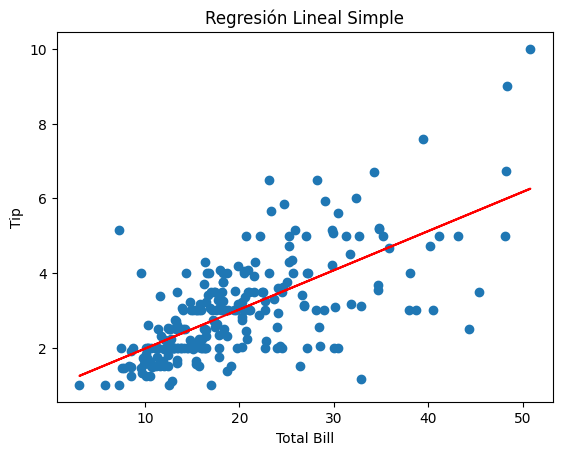

In [23]:
# Visualizar regresión lineal
plt.plot(df_tips["total_bill"], df_tips["tip"], 'o')
plt.plot(df_tips["total_bill"], beta * df_tips["total_bill"] + alpha, 'r-')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal Simple')
plt.show()

In [32]:
# Iterar pérdida de la regresión lineal

num_it = 100
perdida = []

for i in range(num_it):

  y_pred = np.polyval(linear_regression, df_tips["total_bill"])
  error = ((y_pred_lr - y_pred)**2).mean()
  perdida.append(error)


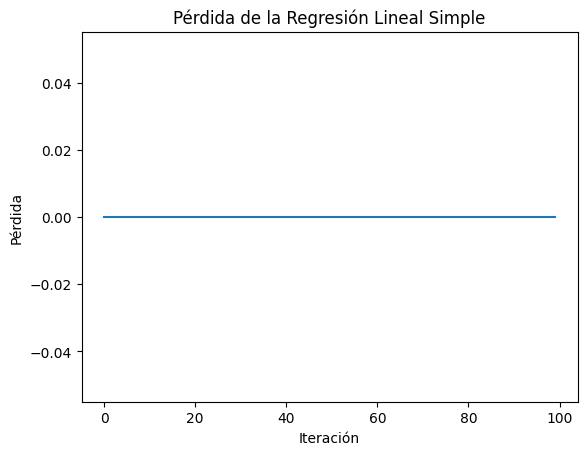

In [33]:
# Visualizar pérdida de la regresión lineal

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Pérdida de la Regresión Lineal Simple')
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [34]:
# Definir parámetros

paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [36]:
# Realizar algoritmo del descenso de gradiente

iteraciones = 100

for i in range(iteraciones):
  y_pred = theta_1 * df_tips["total_bill"] + theta_0
  error = ((y_pred_lr - y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2/len(df_tips["total_bill"])) * np.sum(y_pred - df_tips["tip"])
  d_theta_1 = (2/len(df_tips["total_bill"])) * np.sum((y_pred - df_tips["tip"]) * df_tips["total_bill"])

  theta_0 = theta_0 - paso * d_theta_0
  theta_1 = theta_1 - paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 0.1409985494835289 x + 0.06528993825654399


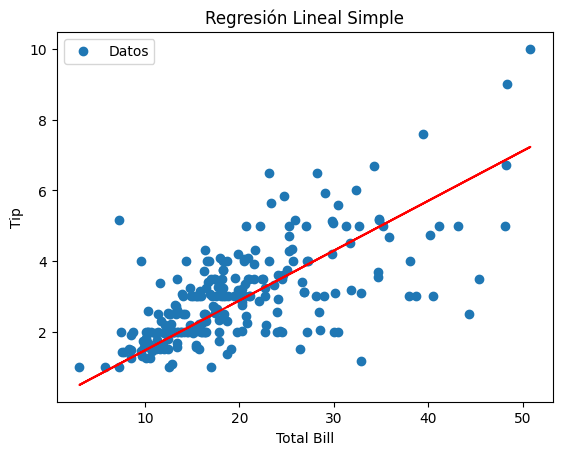

In [42]:
# Visualizar la regresión lineal por descenso de gradiente

plt.plot(df_tips["total_bill"], df_tips["tip"] , 'o', label = 'Datos')
plt.plot(df_tips["total_bill"], theta_1 * df_tips["total_bill"] + theta_0, 'r-')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.show()

In [38]:
# Predicción de valores con descenso de gradiente

tb_pred_gd = int(input('Agrega el valor total de la cuenta que deseas predecir la propina: '))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'La propina será de {y_pred_gd}')

Agrega el valor total de la cuenta que deseas predecir la propina: 5000
La propina será de 705.06


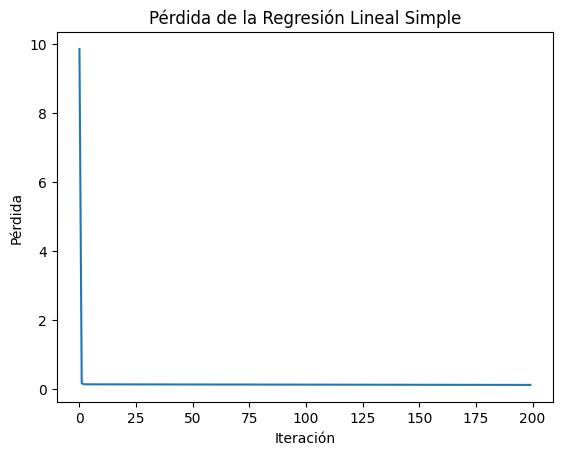

In [44]:
# Visualizar las pérdidas

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Pérdida de la Regresión Lineal Simple')
plt.show()

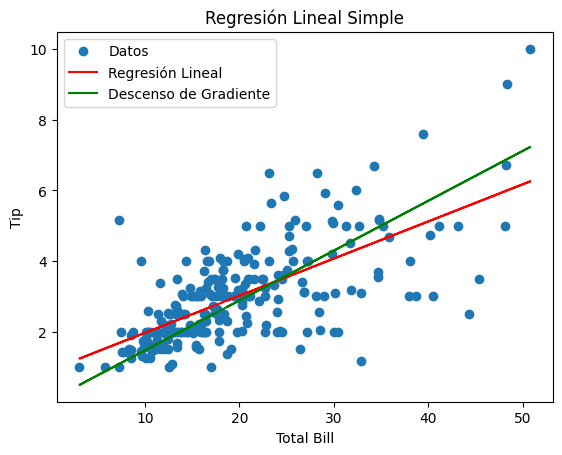

In [45]:
# Comparar las rectas obtenidas por los algoritmos

plt.plot(df_tips["total_bill"], df_tips["tip"] , 'o', label = 'Datos')
plt.plot(df_tips["total_bill"], beta * df_tips["total_bill"] + alpha, 'r-', label = 'Regresión Lineal')
plt.plot(df_tips["total_bill"], theta_1 * df_tips["total_bill"] + theta_0, 'g-', label = 'Descenso de Gradiente')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [54]:
# Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [55]:
# Importar dataset

df_taxis = sns.load_dataset('taxis')
df_taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [56]:
# Importar módulo
from scipy import stats

In [57]:
# Separación de grupos

yellow = df_taxis[df_taxis['color'] == 'yellow']['distance']
green = df_taxis[df_taxis['color'] == 'green']['distance']

In [60]:
# Aplicar Prueba T de Student

t_statistic, p_value = stats.ttest_ind(yellow, green)

print(f'Estadístico t: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

Estadístico t: -3.4060
p-value: 0.0007


In [61]:
# Interpretación automática


if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre las propinas de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre las propinas de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre las propinas de ambos grupos.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que las propinas son diferentes.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre las propinas de ambos grupos.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [62]:
# Definir regresión lineal

linear_regression = np.polyfit(df_taxis["distance"],df_taxis["fare"],1)
beta, alpha = linear_regression


print(f'y = {beta} x + {alpha}')

y = 2.776717185794716 x + 4.692567091217987


In [88]:
# Realizar algoritmo del descenso de gradiente

paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []

iteraciones = 100


for i in range(iteraciones):

  t_pred = theta_1 * df_taxis["distance"] + theta_0
  error = ((df_taxis["fare"] - y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2/len(df_taxis["distance"])) * np.sum(t_pred - df_taxis["fare"])
  d_theta_1 = (2/len(df_taxis["distance"])) * np.sum((t_pred - df_taxis["fare"]) * df_taxis["distance"])

  theta_0 = theta_0 - paso * d_theta_0
  theta_1 = theta_1 - paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 3.245257878356602 x + 0.9174503569152676


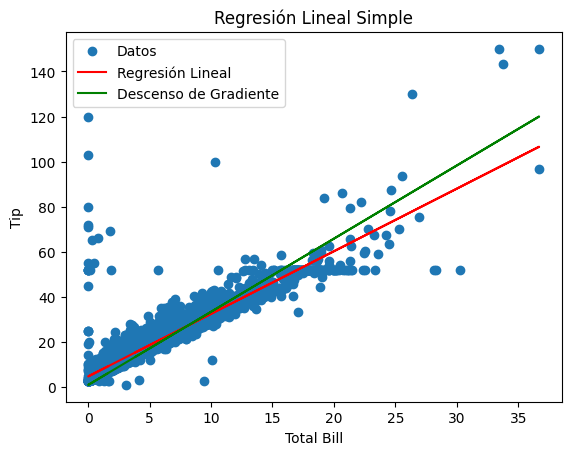

In [89]:
# Comparar las rectas obtenidas por los algoritmos

plt.plot(df_taxis["distance"], df_taxis["fare"] , 'o', label = 'Datos')
plt.plot(df_taxis["distance"], beta * df_taxis["distance"] + alpha, 'r-', label = 'Regresión Lineal')
plt.plot(df_taxis["distance"], theta_1 * df_taxis["distance"] + theta_0, 'g-', label = 'Descenso de Gradiente')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.show()

**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

In [90]:
# Invocacion de regresión lineal

linear_regression = np.polyfit(df_taxis["distance"],df_taxis["fare"],1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 2.776717185794716 x + 4.692567091217987


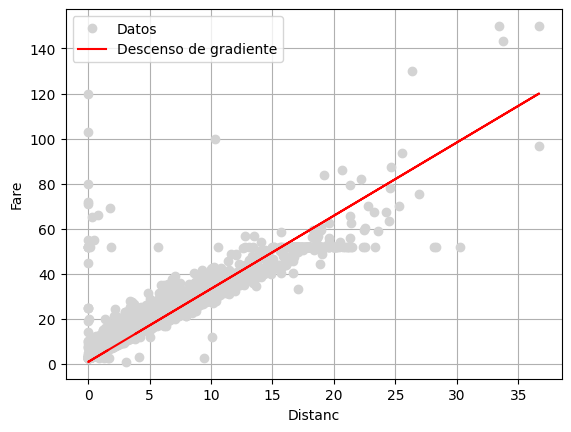

In [91]:
# Predicción de valores con descenso de gradiente

plt.plot(df_taxis["distance"], df_taxis["fare"], 'o', color = 'lightgray', label = 'Datos')
plt.plot(df_taxis["distance"], theta_1 * df_taxis["distance"] + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('Distanc')
plt.ylabel('Fare')
plt.legend()
plt.grid()
plt.show()

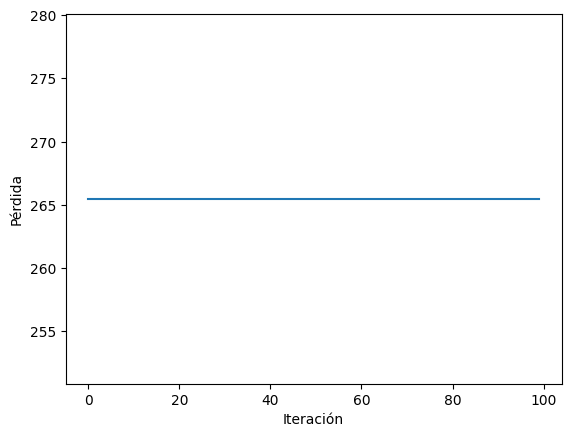

In [92]:
# Visualizar función de costo

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()